# Bisector
Bisector adalah metode defuzzifikasi yang mencari titik potong $x^*$ pada sumbu horizontal yang membagi luas total di bawah kurva himpunan fuzzy output menjadi dua bagian yang sama persis.

Ngga kayak Centroid yang mencari titik keseimbangan, Bisector mencari titik yang membagi area menjadi 50% di kiri dan 50% di kanan.

secara konsep Bisector $x^*_{\text{BoA}}$ adalah titik pada domain x sedemikian rupa sehingga luas area di bawah kurva $\mu_C(x)$ dari batas awal domain (x min) hingga $x^*_{\text{BoA}}$ sama dengan setengah dari luas total di bawah kurva.

$$
\int_{x_{\min}}^{x^*_{\text{BoA}}} \mu_C(x)\, dx \;=\; 
\frac{1}{2} \int_{x_{\min}}^{x_{\max}} \mu_C(x)\, dx
$$

Wait, agak burn out. nanti lanjut hehe

## Visualisasinya

C:\Users\Dipo\AppData\Local\Temp\ipykernel_49352\3921459660.py:29: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  total_area = trapz(mu_C, x)


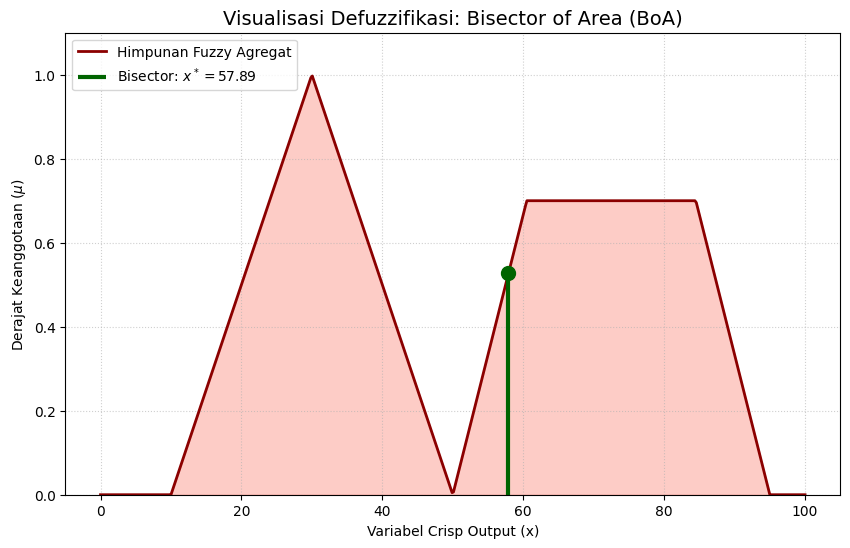

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapz

# --- 1. Definisikan Himpunan Fuzzy Output Agregat ---

x = np.linspace(0, 100, 500)

# Fungsi Keanggotaan (Digunakan untuk agregasi)
def triangular_mf(x, a, m, b):
    return np.maximum(0, np.minimum((x - a) / (m - a), (b - x) / (b - m)))

def trapezoidal_mf(x, a, b, c, d):
    return np.maximum(0, np.minimum(np.minimum((x - a) / (b - a), 1), (d - x) / (d - c)))

# Himpunan A (Segitiga Tinggi, mu=1.0)
mu_A = triangular_mf(x, 10, 30, 50)

# Himpunan B (Trapesium Rendah, mu=0.7)
mu_B_full = trapezoidal_mf(x, 50, 65, 80, 95)
mu_B = np.minimum(mu_B_full, 0.7) 

# Himpunan Output Agregat (Union/MAX)
mu_C = np.maximum(mu_A, mu_B)

# --- 2. Terapkan Bisector of Area (BoA) ---

# Hitung Luas Total (Menggunakan integrasi trapesium/trapz)
total_area = trapz(mu_C, x)
half_area = total_area / 2

# Cari titik x* di mana area kumulatif mencapai half_area
cumulative_area = 0
x_star_BoA = 0
for i in range(len(x) - 1):
    # Luas trapesium kecil antara x[i] dan x[i+1]
    dx = x[i+1] - x[i]
    area_segment = (mu_C[i] + mu_C[i+1]) / 2 * dx
    cumulative_area += area_segment
    
    if cumulative_area >= half_area:
        # Jika sudah melewati setengah area, gunakan interpolasi linier sederhana
        x_star_BoA = x[i] + (half_area - (cumulative_area - area_segment)) / area_segment * dx
        break

# --- 3. Visualisasi dengan Matplotlib ---

plt.figure(figsize=(10, 6))

# Plot Kurva Himpunan Fuzzy Agregat
plt.plot(x, mu_C, label='Himpunan Fuzzy Agregat', color='darkred', linewidth=2)
plt.fill_between(x, mu_C, 0, alpha=0.4, color='salmon')

# Tandai Garis Bisector (BoA)
mu_at_bisector = mu_C[np.argmin(np.abs(x - x_star_BoA))] # Nilai mu di x_star
plt.vlines(x_star_BoA, 0, mu_at_bisector, color='darkgreen', linestyle='-', linewidth=3, 
           label=f'Bisector: $x^* = {x_star_BoA:.2f}$')
plt.scatter(x_star_BoA, mu_at_bisector, color='darkgreen', s=100, zorder=5)

# Label dan Judul
plt.title('Visualisasi Defuzzifikasi: Bisector of Area (BoA)', fontsize=14)
plt.xlabel('Variabel Crisp Output (x)')
plt.ylabel('Derajat Keanggotaan ($\mu$)')
plt.ylim(0, 1.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.show()